# ASL Sign Language CNN Training
**Kernel: Python (signlang)**

Trains MobileNetV2 on `dataset/` (A-R, ~1000 imgs/class, 400×400 RGB).  
Saves → `Sign language/Model/keras_model.h5` + `labels.txt`

In [1]:
import os, pathlib, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras

print('TF  :', tf.__version__)
print('GPU :', tf.config.list_physical_devices('GPU'))

TF  : 2.13.1
GPU : []


In [ ]:
NOTEBOOK_DIR = pathlib.Path('.').resolve()
DATASET_DIR  = NOTEBOOK_DIR.parent / 'dataset'
MODEL_OUT    = NOTEBOOK_DIR / 'Model' / 'keras_model.h5'
LABELS_OUT   = NOTEBOOK_DIR / 'Model' / 'labels.txt'

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS_WARM = 5
EPOCHS_FINE = 20
SEED        = 42

classes = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(classes)
print(f'Dataset : {DATASET_DIR}')
print(f'Classes ({NUM_CLASSES}): {classes}')

Dataset : C:\Users\Quassar\Downloads\Sign-Language-Interpreter-using-Deep-Learning\dataset
Classes (26): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [3]:
# ── Collect paths & labels ────────────────────────────────────────────────────
all_paths, all_labels = [], []
for idx, cls in enumerate(classes):
    for p in (DATASET_DIR / cls).glob('*.jpg'):
        all_paths.append(str(p))
        all_labels.append(idx)

print(f'Total images: {len(all_paths)}')

X_tr, X_val, y_tr, y_val = train_test_split(
    all_paths, all_labels, test_size=0.15, stratify=all_labels, random_state=SEED
)
print(f'Train: {len(X_tr)}   Val: {len(X_val)}')

Total images: 26000
Train: 22100   Val: 3900


In [4]:
# ── tf.data pipeline ──────────────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

def load(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return tf.cast(img, tf.float32) / 255.0, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    return tf.clip_by_value(img, 0.0, 1.0), label

train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
            .shuffle(len(X_tr), seed=SEED)
            .map(load,    num_parallel_calls=AUTOTUNE)
            .map(augment, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .map(load, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE).prefetch(AUTOTUNE))

print('Datasets ready.')

Datasets ready.


In [5]:
# ── Build model ───────────────────────────────────────────────────────────────
base = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base(inputs, training=False)
x       = keras.layers.GlobalAveragePooling2D()(x)
x       = keras.layers.Dropout(0.3)(x)
x       = keras.layers.Dense(256, activation='relu')(x)
x       = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0     

In [6]:
# ── Phase 1: Warm-up ──────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb_warm = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]

print('=== Phase 1: Warm-up (head only) ===')
h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_WARM, callbacks=cb_warm)

=== Phase 1: Warm-up (head only) ===
Epoch 1/5
691/691 [==============================] - 284s 407ms/step - loss: 0.1918 - accuracy: 0.9476 - val_loss: 0.0175 - val_accuracy: 0.9946 - lr: 0.0010
Epoch 2/5
691/691 [==============================] - 276s 399ms/step - loss: 0.0308 - accuracy: 0.9905 - val_loss: 0.0121 - val_accuracy: 0.9969 - lr: 0.0010
Epoch 3/5
691/691 [==============================] - 277s 401ms/step - loss: 0.0230 - accuracy: 0.9922 - val_loss: 0.0084 - val_accuracy: 0.9969 - lr: 0.0010
Epoch 4/5
691/691 [==============================] - 279s 404ms/step - loss: 0.0225 - accuracy: 0.9927 - val_loss: 0.0051 - val_accuracy: 0.9974 - lr: 0.0010
Epoch 5/5
691/691 [==============================] - 283s 410ms/step - loss: 0.0167 - accuracy: 0.9944 - val_loss: 0.0024 - val_accuracy: 0.9992 - lr: 0.0010


In [7]:
# ── Phase 2: Fine-tune ────────────────────────────────────────────────────────
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb_fine = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=3),
    keras.callbacks.ModelCheckpoint(
        str(MODEL_OUT), save_best_only=True, monitor='val_accuracy', verbose=1
    )
]

print('=== Phase 2: Fine-tuning (top 30 layers) ===')
h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE, callbacks=cb_fine)

=== Phase 2: Fine-tuning (top 30 layers) ===
Epoch 1/20
691/691 [==============================] - ETA: 0s - loss: 0.0369 - accuracy: 0.9908
Epoch 1: val_accuracy improved from -inf to 0.99923, saving model to C:\Users\Quassar\Downloads\Sign-Language-Interpreter-using-Deep-Learning\Sign language\Model\keras_model.h5
691/691 [==============================] - 345s 494ms/step - loss: 0.0369 - accuracy: 0.9908 - val_loss: 0.0031 - val_accuracy: 0.9992 - lr: 1.0000e-04
Epoch 2/20
691/691 [==============================] - ETA: 0s - loss: 0.0101 - accuracy: 0.9975
Epoch 2: val_accuracy improved from 0.99923 to 1.00000, saving model to C:\Users\Quassar\Downloads\Sign-Language-Interpreter-using-Deep-Learning\Sign language\Model\keras_model.h5
691/691 [==============================] - 341s 494ms/step - loss: 0.0101 - accuracy: 0.9975 - val_loss: 2.7695e-04 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 3/20
691/691 [==============================] - ETA: 0s - loss: 0.0177 - accuracy: 0.9953
Ep

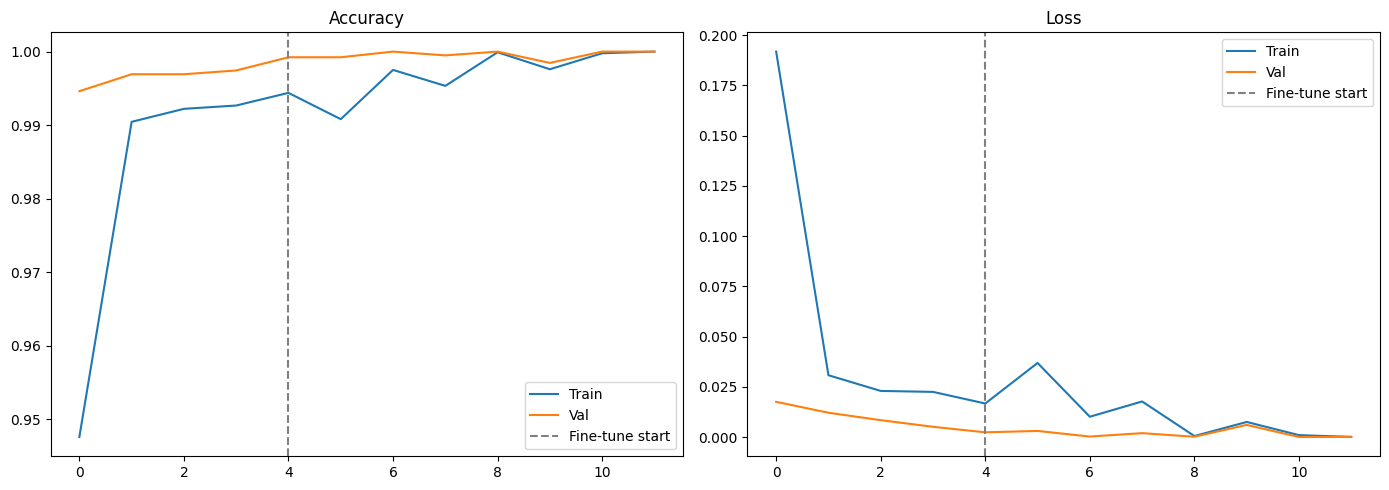

Best val accuracy: 100.00%


In [8]:
# ── Training curves ───────────────────────────────────────────────────────────
acc  = h1.history['accuracy']     + h2.history['accuracy']
vacc = h1.history['val_accuracy'] + h2.history['val_accuracy']
loss = h1.history['loss']         + h2.history['loss']
vloss= h1.history['val_loss']     + h2.history['val_loss']
split = len(h1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr, vl, title in zip(axes, [acc, loss], [vacc, vloss], ['Accuracy', 'Loss']):
    ax.plot(tr, label='Train'); ax.plot(vl, label='Val')
    ax.axvline(split - 1, color='gray', linestyle='--', label='Fine-tune start')
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()
print(f'Best val accuracy: {max(vacc)*100:.2f}%')

122/122 [==============================] - 58s 465ms/step
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       150
           B       1.00      1.00      1.00       150
           C       1.00      1.00      1.00       150
           D       1.00      1.00      1.00       150
           E       1.00      1.00      1.00       150
           F       1.00      1.00      1.00       150
           G       1.00      1.00      1.00       150
           H       1.00      1.00      1.00       150
           I       1.00      1.00      1.00       150
           J       1.00      1.00      1.00       150
           K       1.00      1.00      1.00       150
           L       1.00      1.00      1.00       150
           M       1.00      1.00      1.00       150
           N       1.00      1.00      1.00       150
           O       1.00      1.00      1.00       150
           P       1.00      1.00      1.00       150
           Q       1.00

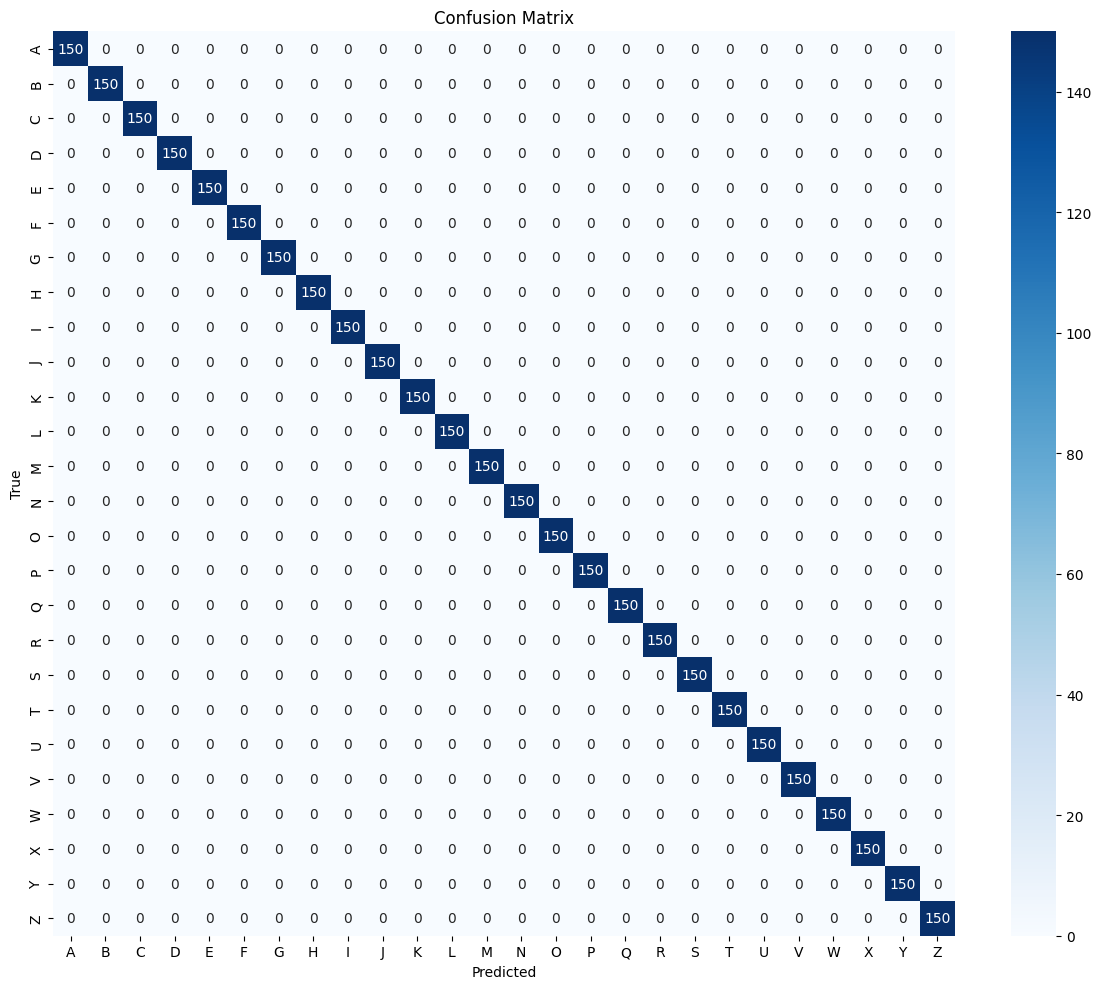

In [9]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
y_pred = np.argmax(model.predict(val_ds), axis=1)
print(classification_report(y_val, y_pred, target_names=classes))

plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d',
            xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title('Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

In [10]:
# ── Save labels.txt ───────────────────────────────────────────────────────────
# Model is already saved by ModelCheckpoint above (best val_accuracy)
MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
with open(LABELS_OUT, 'w') as f:
    for idx, cls in enumerate(classes):
        f.write(f'{idx} {cls}\n')

print(f'Model  → {MODEL_OUT}')
print(f'Labels → {LABELS_OUT}')
print('Restart the backend to load the new model.')

Model  → C:\Users\Quassar\Downloads\Sign-Language-Interpreter-using-Deep-Learning\Sign language\Model\keras_model.h5
Labels → C:\Users\Quassar\Downloads\Sign-Language-Interpreter-using-Deep-Learning\Sign language\Model\labels.txt
Restart the backend to load the new model.


In [ ]:
# ── Save model weights as HDF5 ───────────────────────────────────────────────
WEIGHTS_OUT = MODEL_OUT.parent / 'model_weights.h5'

model.save_weights(str(WEIGHTS_OUT))

print(f'Weights → {WEIGHTS_OUT}')
